In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

**WRITE A PYTHON PROGRAM TO IMPLEMENT PERCEPTRON WITH DECESION BOUNDARY**

In [2]:
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Training Data
# [Study,Hours,Attendence]
X = np.array([
    [1,50],
    [2,55],
    [3,60],
    [5,75],
    [6,80],
    [7,85]
])

# Target
# 0=Fail,1=Pass
y = np.array([0,0,0,1,1,1])


# Create Perceptron Model
model = Perceptron(max_iter=1000, random_state=42)

# Train The Model
model.fit(X,y)

# Predictions
y_pred = model.predict(X)

# Display Results
print("Actual Values : ",y)
print("Predicted Values: ",y_pred)

# Accuracy
accuracy = accuracy_score(y,y_pred)

print("Accuracy : ",accuracy *100, "%")

# Model parameters
print("\nWeights : ",model.coef_)
print("Bias : ",model.intercept_)


# Predict a New Student
new_student = np.array([[4,70]])

prediction =model.predict(new_student)

if prediction[0]==1:
    print("\nNew Student Prediction : PASS")
else:
    print("\nNew Strudent Prediction : FAIL")


Actual Values :  [0 0 0 1 1 1]
Predicted Values:  [0 0 0 0 0 0]
Accuracy :  50.0 %

Weights :  [[ 38. -15.]]
Bias :  [-6.]

New Strudent Prediction : FAIL


Actual Values :  [0 0 0 1 1 1]
Predicted Values:  [0 0 0 1 1 1]

New Student Prediction : PASS


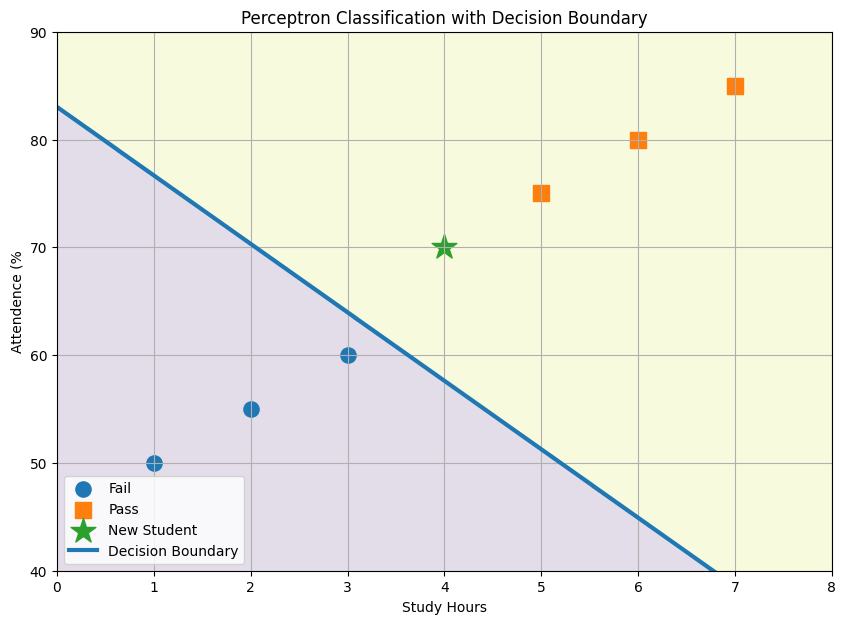

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Datasets
# --------------------------------------------------
# [Study,Hours,Attendence]
X = np.array([
    [1,50],
    [2,55],
    [3,60],
    [5,75],
    [6,80],
    [7,85]
])

# 0=Fail,1=Pass
y = np.array([0,0,0,1,1,1])


# ----------------------------------------------------------
# Perceptron with Scaling
# -----------------------------------------------------------
model = make_pipeline(
    StandardScaler(),
    Perceptron(max_iter=1000, random_state=42)
)

model.fit(X,y)

predictions = model.predict(X)

print("Actual Values : ",y)
print("Predicted Values: ",predictions)


# New Student 
new_student = np.array([[4,70]])

prediction =model.predict(new_student)

if prediction[0]==1:
    print("\nNew Student Prediction : PASS")
else:
    print("\nNew Strudent Prediction : FAIL")

X_min,X_max = 0,8
y_min,y_max = 40,90

xx,yy = np.meshgrid(
    np.linspace(X_min,X_max,200),
    np.linspace(y_min,y_max,200)
)

grid = np.c_[xx.ravel(),yy.ravel()]

Z =model.predict(grid)

Z = Z.reshape(xx.shape)


plt.figure(figsize =(10,7))

# Decision regions
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.15
    
)

# Fail Points
plt.scatter(
    X[y == 0,0],
    X[y == 0,1],
    marker = 'o',
    s=120,
    label = 'Fail'
)

# Pass Points
plt.scatter(
    X[y == 1,0],
    X[y == 1,1],
    marker = 's',
    s=120,
    label = 'Pass'
)

plt.scatter (
    new_student[0,0],
    new_student[0,1],
    marker = '*',
    s = 350,
    label = "New Student"
)

# get transformed -space coeficients
Scaler = model.named_steps['standardscaler']
perceptron = model.named_steps['perceptron']

w = perceptron.coef_[0]
b = perceptron.intercept_[0]

# Convert bpundary back to original feature space
mean = Scaler.mean_
scale = Scaler.scale_

w_original = w/scale

b_original = b- np.sum(w*mean/scale)

x_values = np.linspace(0,8,100)

y_values = -(
    w_original[0] * x_values + b_original
)/w_original[1]

plt.plot(
    x_values,
    y_values,
    linewidth = 3,
    label = "Decision Boundary"
)

plt.xlabel("Study Hours")
plt.ylabel("Attendence (%")

plt.title("Perceptron Classification with Decision Boundary")
plt.legend()
plt.grid(True)

plt.xlim(0,8)
plt.ylim(40,90)

plt.show()

K = 3
Prediction : PASS

Nearest Neighbors:
Student 7 Distance = 0.0 Class = PASS
Student 2 Distance = 5.1 Class = PASS
Student 5 Distance = 10.05 Class = FAIL


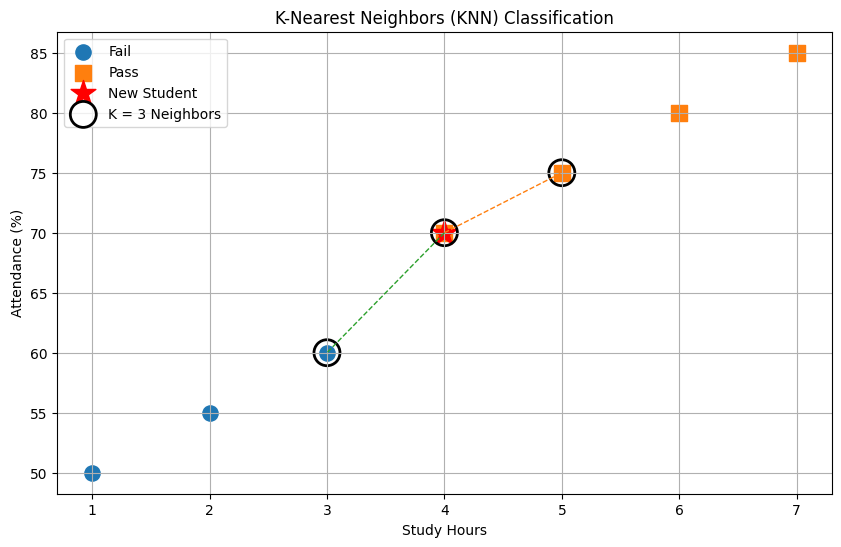

In [24]:
# ================================================
# KNN CLASSIFICATION WITH VISUALIZATION
# ================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier

# Dataset
X = np.array([
    [2, 55],
    [5, 75],
    [1, 50],
    [6, 80],
    [3, 60],
    [7, 85],
    [4, 70]
])

# 0 = FAIL, 1 = PASS
# Added the missing label for [4,70]
y = np.array([0, 1, 0, 1, 0, 1, 1])

k = 3

knn = KNeighborsClassifier(n_neighbors=k)

# Train the Model
knn.fit(X, y)

# =================================================
# NEW DATA POINT
# =================================================

new_student = np.array([[4, 70]])

prediction = knn.predict(new_student)

print("K =", k)

if prediction[0] == 1:
    print("Prediction : PASS")
else:
    print("Prediction : FAIL")

# =================================================
# FIND NEAREST NEIGHBORS
# =================================================

distances, indices = knn.kneighbors(new_student)

print("\nNearest Neighbors:")

for i in range(k):
    index = indices[0][i]

    print(
        "Student", index + 1,
        "Distance =", round(distances[0][i], 2),
        "Class =",
        "PASS" if y[index] == 1 else "FAIL"
    )

# =================================================
# VISUALIZATION
# =================================================

plt.figure(figsize=(10, 6))

# Plot FAIL students
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    marker='o',
    s=120,
    label='Fail'
)

# Plot PASS students
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    marker='s',
    s=120,
    label='Pass'
)

# Plot new student
plt.scatter(
    new_student[0, 0],
    new_student[0, 1],
    marker='*',
    s=350,
    color='red',
    label='New Student'
)

# Get nearest neighbors
nearest = X[indices[0]]

# Highlight nearest neighbors
plt.scatter(
    nearest[:, 0],
    nearest[:, 1],
    facecolor='none',
    edgecolor='black',
    s=350,
    linewidth=2,
    label='K = 3 Neighbors'
)

# Draw lines from new student to neighbors
for point in nearest:
    plt.plot(
        [new_student[0, 0], point[0]],
        [new_student[0, 1], point[1]],
        linestyle='--',
        linewidth=1
    )

plt.xlabel("Study Hours")
plt.ylabel("Attendance (%)")

plt.title("K-Nearest Neighbors (KNN) Classification")

plt.legend()
plt.grid(True)

plt.show()